<a href="https://colab.research.google.com/github/AyaAbdElNaem/Deep_Learning/blob/main/AS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import glob
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
def get_sorted_file_paths(data_dir):
    all_paths = sorted(glob.glob(os.path.join(data_dir, "*.png")))
    image_paths = all_paths[0::2]
    mask_paths = all_paths[1::2]
    return image_paths, mask_paths
    #used twice [once in training & the other in testing]

In [7]:
train_data=get_sorted_file_paths("/content/drive/MyDrive/training_set")

In [12]:
import matplotlib.pyplot as plt
import cv2

first_image_path = train_data[0][0]
first_mask_path  = train_data[1][0]

img = cv2.imread(first_image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(first_mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Original Image:\n{os.path.basename(first_image_path)}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title(f"Annotation Mask:\n{os.path.basename(first_mask_path)}")
plt.axis('off')

plt.show()

In [9]:
# for idx in range(len(train_data[0])):
#     img_path = train_data[0][idx]
#     mask_path = train_data[1][idx]

#     # قراءة الصورة والماسك بأبعادهم الأصلية من الهارد ديسك
#     img = cv2.imread(img_path)
#     mask = cv2.imread(mask_path)

#     # استخراج الارتفاع والعرض الفعلي
#     h, w, c = img.shape
#     mh, mw, mc = mask.shape

#     print(f"case number [{idx+1}]:")
#     print(f" file : {os.path.basename(img_path)}")
#     print(f"  Image dimensions : {h} × {w} pixel")
#     print(f"  Mask dimensions :  {mh} × {mw} pixel")

case number [1]:
 file : 000_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [2]:
 file : 001_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [3]:
 file : 002_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [4]:
 file : 003_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [5]:
 file : 004_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [6]:
 file : 005_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [7]:
 file : 006_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [8]:
 file : 007_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case number [9]:
 file : 008_HC.png
  Image dimensions : 540 × 800 pixel
  Mask dimensions :  540 × 800 pixel
case numbe

KeyboardInterrupt: 

In [14]:
def convert_contour_to_filled_mask(ann_image):
    """تأخذ صورة الخط الرفيع المفرغ وتحولها إلى قناع (Mask) ممتلئ تماماً باللون الأبيض"""
    contours, _ = cv2.findContours(ann_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(ann_image)

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=-1)

    return filled_mask

In [32]:
class UltrasoundHCDataset(Dataset):
    def __init__(self, data_path, img_size=(512, 512)):
        self.image_paths, self.mask_paths = get_sorted_file_paths(data_path)
        self.img_size = img_size
        assert len(self.image_paths) == len(self.mask_paths),"Folder file sequence/count mismatch!"
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load the original grayscale ultrasound image
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, self.img_size)

        # 2. IMAGE PREPROCESSING STEP
        # A. Noise Reduction using median & Gaussian Blur
        # median_filtered = cv2.medianBlur(image, 5)
        # blurred_image = cv2.GaussianBlur(median_filtered, (5, 5), 0)
        bilateral_image = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

        # B. Edge Detection using Canny Algorithm
        # Thresholds (50, 150) are standard for standardizing ultrasound boundaries
        # edges = cv2.Canny(bilateral_image, threshold1=50, threshold2=150)

        #Edge Detection using sobel Algorithm
        sobel_x = cv2.Sobel(bilateral_image, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(bilateral_image, cv2.CV_64F, 0, 1, ksize=3)
        edges = cv2.magnitude(sobel_x, sobel_y)
        edges = cv2.normalize(edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # C. Feature Fusion: Combine original image and extracted edges
        # This helps the U-Net model see both the overall anatomy and sharp boundaries
        processed_image = cv2.addWeighted(bilateral_image, 0.7, edges, 0.3, 0)

        # 3. Load the Annotation and convert it to a completely filled binary mask
        ann_image = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        ann_image = cv2.resize(ann_image, self.img_size)
        filled_mask = convert_contour_to_filled_mask(ann_image)

        # 4. Convert processed images and masks to PyTorch Tensors [0, 1]
        image_tensor = TF.to_tensor(processed_image).float()
        mask_tensor = TF.to_tensor(filled_mask).float()
        mask_tensor = (mask_tensor > 0.5).float()

        return image_tensor, mask_tensor

In [33]:
train_dataset = UltrasoundHCDataset(data_path=("/content/drive/MyDrive/training_set"), img_size=(512, 512))

--- Verifying Data After Transformations ---
image_tensor shape: torch.Size([1, 512, 512])
mask_tensor shape:  torch.Size([1, 512, 512])
Image Max Value: 0.95 | Min Value: 0.00
Unique values in mask: tensor([0., 1.])


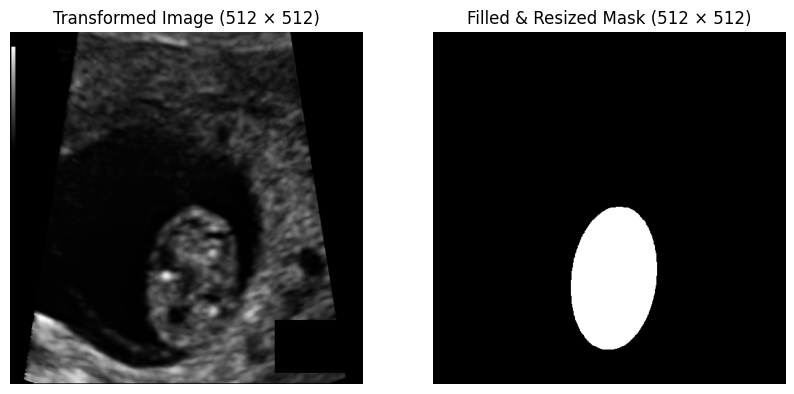

In [17]:
# # 2. Manually pull the first sample (index 0) to test it
# # This will automatically trigger the __getitem__ method and return the modified Tensors
# img_tensor, mask_tensor = train_dataset[0]

# # 3. Print shapes and pixel value ranges for programmatic verification before plotting
# print("--- Verifying Data After Transformations ---")
# print(f"image_tensor shape: {img_tensor.shape}")  # Should output: [1, 512, 512]
# print(f"mask_tensor shape:  {mask_tensor.shape}")   # Should output: [1, 512, 512]
# print(f"Image Max Value: {img_tensor.max():.2f} | Min Value: {img_tensor.min():.2f}")  # Verification that it's normalized [0, 1]
# print(f"Unique values in mask: {mask_tensor.unique()}")  # Verification that it's strictly binary [0.0, 1.0]

# # 4. Convert Tensors to standard NumPy arrays suitable for Matplotlib plotting
# # .squeeze() removes the channel dimension [1, 512, 512] -> [512, 512] since it's grayscale
# #مكتبة PyTorch ترتب أبعاد الصورة كـ [Channels, Height, Width]، بينما مكتبة العرض matplotlib تطلبها بترتيب [Height, Width, Channels].
# # لذلك سنستخدم دالة .permute() أو .squeeze() لتهيئة الأبعاد للعرض بشكل صحيح.
# img_to_show = img_tensor.squeeze().numpy()
# mask_to_show = mask_tensor.squeeze().numpy()

# # 5. Plot both images side-by-side to visually inspect the results
# plt.figure(figsize=(10, 5))

# # Display the resized and normalized ultrasound image
# plt.subplot(1, 2, 1)
# plt.imshow(img_to_show, cmap='gray')
# plt.title("Transformed Image (512 × 512)")
# plt.axis('off')

# # Display the completely filled and resized binary mask
# plt.subplot(1, 2, 2)
# plt.imshow(mask_to_show, cmap='gray')
# plt.title("Filled & Resized Mask (512 × 512)")
# plt.axis('off')

# plt.show()

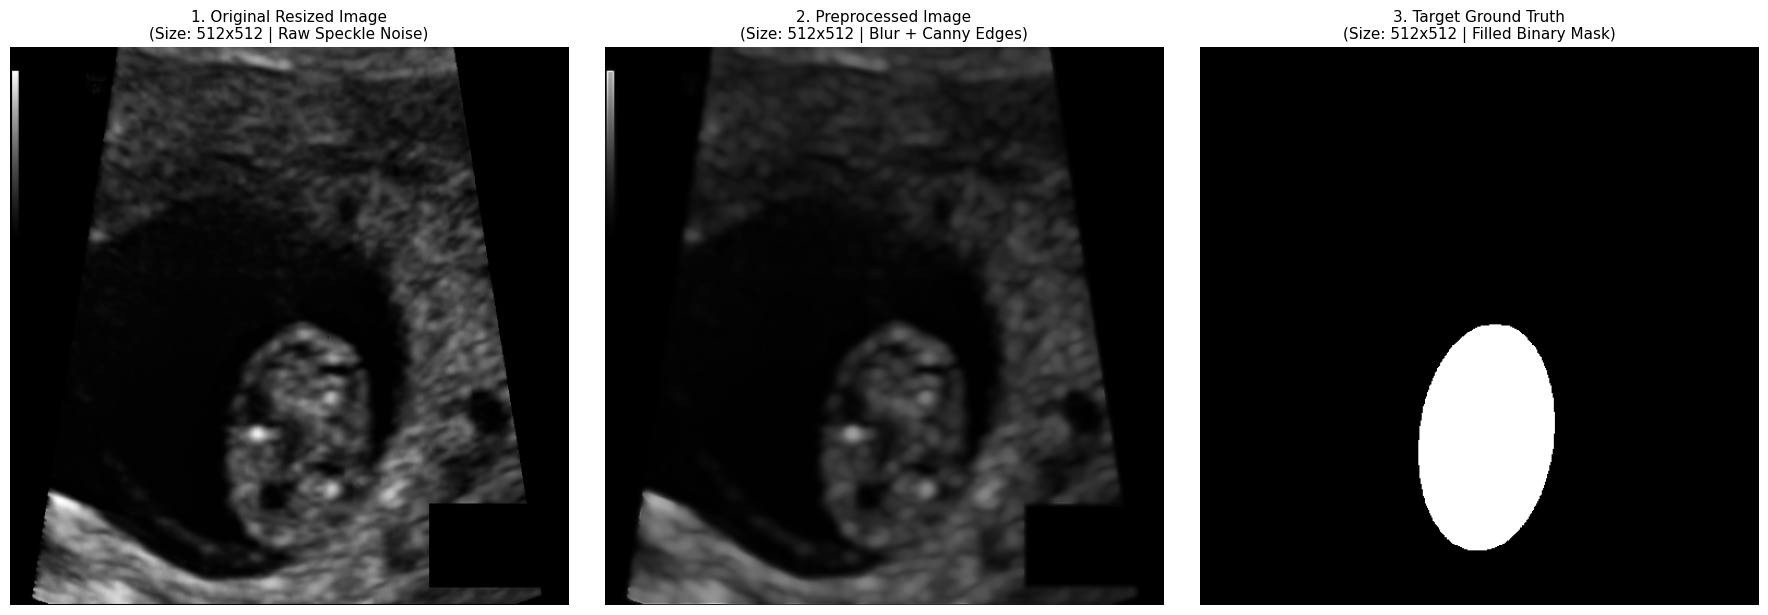

In [34]:
prep_tensor, mask_tensor = train_dataset[0]

# 3. Fetch the exact same original image from outside and apply ONLY resizing
raw_image_path = train_dataset.image_paths[0]
raw_image = cv2.imread(raw_image_path, cv2.IMREAD_GRAYSCALE)

# Apply ONLY square resizing to the original image to match the dimensions fairly
original_resized = cv2.resize(raw_image, (512, 512))

# 4. Extract standard numpy arrays from the train_dataset tensors for plotting
img_after_preprocessing = prep_tensor.squeeze().numpy()
target_mask = mask_tensor.squeeze().numpy()

# =========================================================================
# 5. Plotting the Pure Comparison (Resized vs Preprocessed vs Mask)
# =========================================================================
plt.figure(figsize=(18, 6))

# Plot 1: Original Resized Image (Squeezed to 512x512 with NO filters)
plt.subplot(1, 3, 1)
plt.imshow(original_resized, cmap='gray')
plt.title("1. Original Resized Image\n(Size: 512x512 | Raw Speckle Noise)", fontsize=11)
plt.axis('off')

# Plot 2: Preprocessed Image (Size: 512x512 with Noise Reduced & Edges Enhanced)
plt.subplot(1, 3, 2)
plt.imshow(img_after_preprocessing, cmap='gray')
plt.title("2. Preprocessed Image\n(Size: 512x512 | Blur + Canny Edges)", fontsize=11)
plt.axis('off')

# Plot 3: Target Ground Truth Mask (Size: 512x512 | Solid Filled)
plt.subplot(1, 3, 3)
plt.imshow(target_mask, cmap='gray')
plt.title("3. Target Ground Truth\n(Size: 512x512 | Filled Binary Mask)", fontsize=11)
plt.axis('off')

plt.tight_layout()
plt.show()